# Модель для предсказания возраста посетителей сайтов

Цели и задачи проекта:
  1. Ознакомиться с данными
  2. Проверить их корректность и провести предобработку
  3. Провести исследовательский анализ данных
  4. Обучить, протестировать и выбрать лучшую модель многоклассовой классификация

# Постановка задачи машинного обучения

  - Необходимо решить задачу "обучения с учителем"
  - Целевой переменной явлется переменная 'age_category' из датафрейма df_users, информирующая о возрастной категории, к которой принадлежит пользователь
  - В качестве основной метрики используется F1-мера. Вспомогательные метрики качества: precicion и recall. Критерием успешности проекта является значение F1-меры не меньше 0.75 на кросс-валидации по обучающей выборке, и на тестовой выборке.
    

# Структура проекта

Данное исследование разделим на несколько частей.
  1. [Изучение файлов с данными, получение общей информации, загрузка библиотек](#1)
  2. [Исследовательский анализ данных](#2)
  3. [Создание и отбор признаков](#3)
  4. [Предобработка данных](#4)
  5. [Обучение и оценка базовой модели](#5)
  6. [Подбор гиперпараметров моделей](#6)
  7. [Финальная модель](#7)
  8. [Подготовка артефактов модели для внедрения](#8)
  9. [Выводы о результатах работы](#9)

<a id='1'></a>
## Подготовка среды и библиотек

In [1]:
!pip install phik -q
# для импорта TargetEncoder
!pip install --upgrade scikit-learn -q

In [2]:
import phik as phik
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder, FunctionTransformer, label_binarize
from sklearn.dummy import DummyClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate, cross_val_predict, StratifiedKFold, train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import log_loss, average_precision_score, make_scorer, f1_score, brier_score_loss, roc_auc_score, accuracy_score
from sklearn.metrics import precision_score, fbeta_score, roc_curve, recall_score, precision_recall_curve, classification_report
from sklearn.multiclass import OneVsOneClassifier, OneVsRestClassifier
from sklearn.feature_selection import VarianceThreshold
from time import time
import joblib

In [3]:
# !pip freeze > requirements.txt

In [4]:
RANDOM_SEED = 42

<a id='2'></a>
## Исследовательский анализ данных

In [5]:
df_users = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s13_users.csv')
df_visits = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s13_visits.csv')
df_ads_activity = pd.read_csv('https://code.s3.yandex.net/datasets/ads_activity.csv')
df_surf_depth = pd.read_csv('https://code.s3.yandex.net/datasets/surf_depth.csv')
df_primary_device = pd.read_csv('https://code.s3.yandex.net/datasets/primary_device.csv')
df_cloud_usage = pd.read_csv('https://code.s3.yandex.net/datasets/cloud_usage.csv')

In [6]:
df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5913 entries, 0 to 5912
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   user_id       5913 non-null   object
 1   age_category  5913 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 92.5+ KB


In [7]:
df_visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1065745 entries, 0 to 1065744
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   date              1065745 non-null  object
 1   daytime           1065745 non-null  object
 2   session_id        1065745 non-null  object
 3   user_id           1065745 non-null  object
 4   website_category  1065745 non-null  object
dtypes: object(5)
memory usage: 40.7+ MB


In [8]:
df_ads_activity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5826 entries, 0 to 5825
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   user_id       5826 non-null   object
 1   ads_activity  5826 non-null   object
dtypes: object(2)
memory usage: 91.2+ KB


In [9]:
df_surf_depth.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5715 entries, 0 to 5714
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     5715 non-null   object
 1   surf_depth  5715 non-null   object
dtypes: object(2)
memory usage: 89.4+ KB


In [10]:
df_primary_device.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5669 entries, 0 to 5668
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   user_id         5669 non-null   object
 1   primary_device  5669 non-null   object
dtypes: object(2)
memory usage: 88.7+ KB


In [11]:
df_cloud_usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5680 entries, 0 to 5679
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      5680 non-null   object
 1   cloud_usage  5680 non-null   bool  
dtypes: bool(1), object(1)
memory usage: 50.0+ KB


Данные представлены 6 датафреймами с информацией о пользователях - посетителях сайтов:
  - df_users : 2 столбца и 5913 строк - информация о возрастной категории пользователей
  - df_visits : 5 столбцов и 1_065_745 строк - информация о сеансах пользователей
  - df_ads_activity : 2 столбца и 5826 строк  - информация о характеристиках CTR пользователей
  - df_surf_depth : 2 столбца и 5715 строк - информация о глубине перехода пользователей по сайтам во время одной сессии
  - df_primary_device : 2 столбца и 5669 строк - информация о типе основного устройства пользователей
  - df_cloud_usage : 2 столбца и 5680 строк - информация об обращении пользователей к облачным ресурсам 

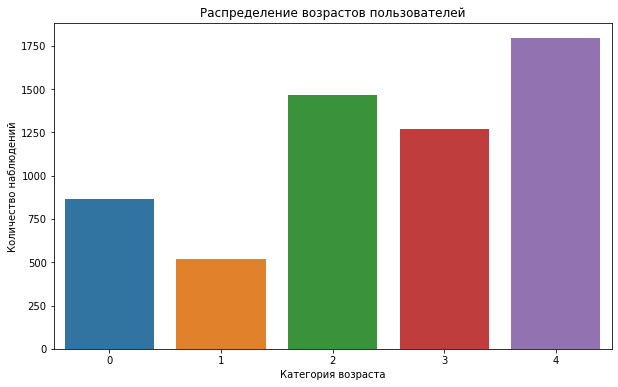

In [12]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_users, x='age_category')
plt.title('Распределение возрастов пользователей')
plt.xlabel('Категория возраста')
plt.ylabel('Количество наблюдений')
plt.show()

Распределние в целевой переменной несбалансиовано, меньше всего пользователей в категории 1 (18-25 лет), а наибольшее число в категориии 4 (56+ лет)

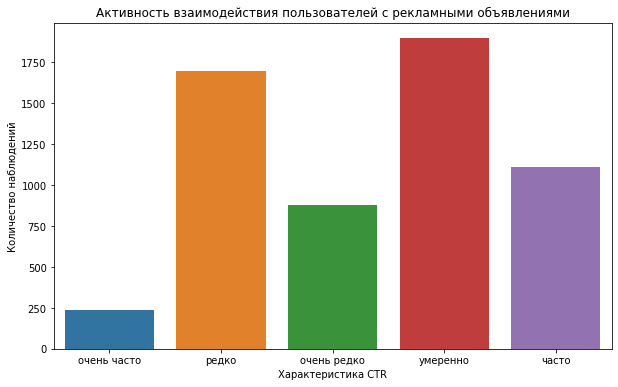

In [13]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_ads_activity, x='ads_activity')
plt.title('Активность взаимодействия пользователей с рекламными объявлениями')
plt.xlabel('Характеристика CTR')
plt.ylabel('Количество наблюдений')
plt.show()

Большая часть пользователей представлена в категориях "умеренно" и "редко", к категории "очень редко" и "часто" относятся примерно одинаковое количество пользователей, меньше всего пользователей в категории "очень часто"

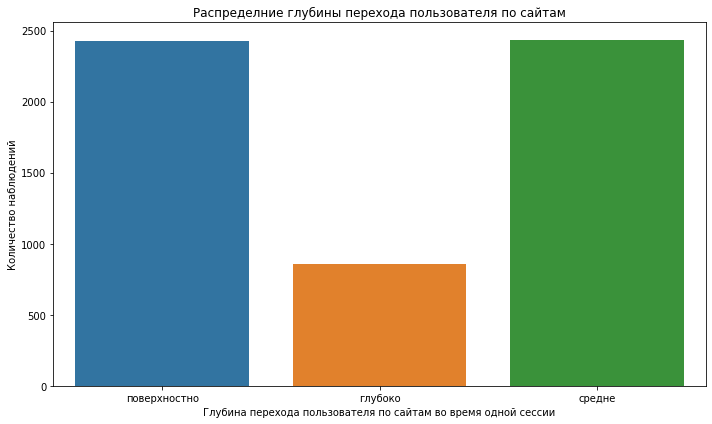

In [14]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_surf_depth, x='surf_depth')
plt.title('Распределние глубины перехода пользователя по сайтам')
plt.xlabel('Глубина перехода пользователя по сайтам во время одной сессии')
plt.ylabel('Количество наблюдений')
plt.tight_layout()
plt.show()

По глубине перехода по сайтам около 85% пользователей отностятся к категориям "поверхностно" и "средне" (~42,5% на каждую), оставшиеся 15% пользователей относятся к категории "глубоко"

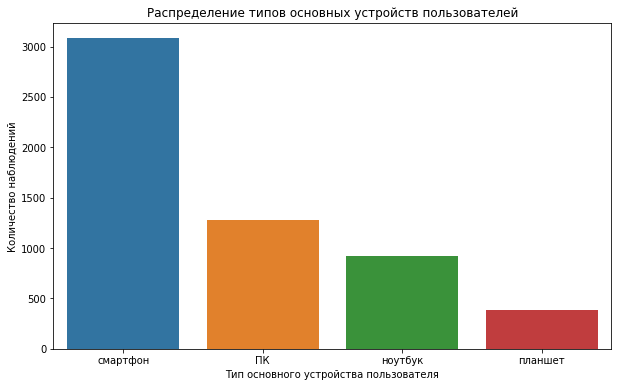

In [15]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_primary_device, x='primary_device')
plt.title('Распределение типов основных устройств пользователей')
plt.xlabel('Тип основного устройства пользователя')
plt.ylabel('Количество наблюдений')
plt.show()

54.4% пользователей в качестве основного устройства используют смартфоны, 22.5% - ПК, 16.3% - ноутбуки и 6.8% - планшеты

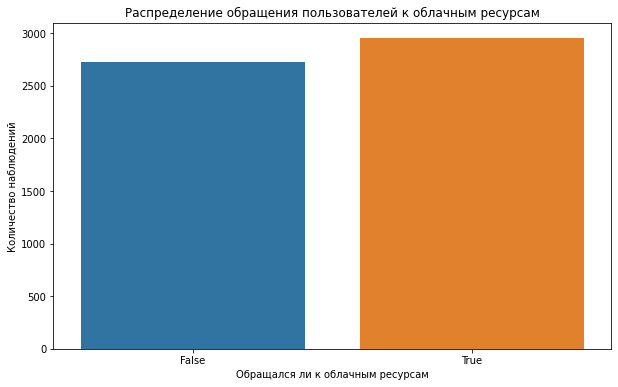

In [16]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_cloud_usage, x='cloud_usage')
plt.title('Распределение обращения пользователей к облачным ресурсам')
plt.xlabel('Обращался ли к облачным ресурсам')
plt.ylabel('Количество наблюдений')
plt.show()

52% пользователей обращаются к облачным ресурсам, 48% не обращаются

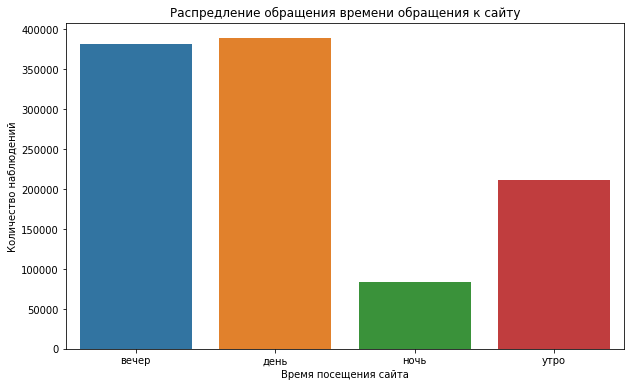

In [17]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_visits, x='daytime')
plt.title('Распредление обращения времени обращения к сайту')
plt.xlabel('Время посещения сайта')
plt.ylabel('Количество наблюдений')
plt.show()

72.6% обращений к сайту происходят вечером и утром (35.8% вечером и 36.5% днем), наименьшее количество обращнений наблюдаются ночью (7.8%) и 19.8% приходятся на утро

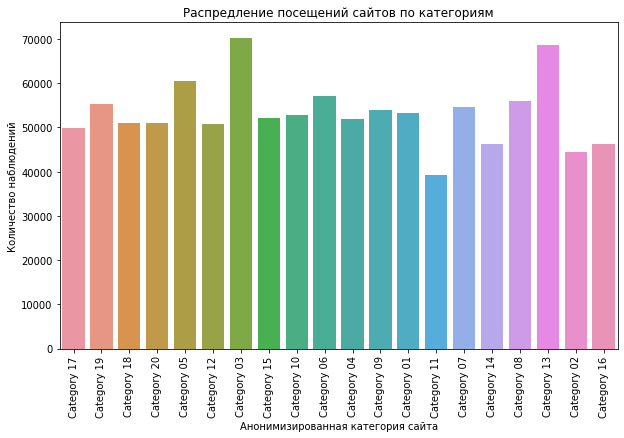

In [18]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_visits, x='website_category')
plt.title('Распредление посещений сайтов по категориям')
plt.xlabel('Анонимизированная категория сайта')
plt.ylabel('Количество наблюдений')
plt.xticks(rotation=90)
plt.show()

Количество наблюдений обращений по катигориям сайтов по большей части распределены равномерно, среди выделяющихся можно отметить 'Category03', 'Category 13' и 'Category 05' как наиболее популярные и 'Category 11', 'Category 02' ,'Category 16', 'Category 14' как наименее популярные. 

In [19]:
df_cloud_usage['cloud_usage'] = df_cloud_usage['cloud_usage'].astype(int)

for table_name, table in [
    ('df_users', df_users),
    ('df_ads_activity', df_ads_activity),
    ('df_surf_depth', df_surf_depth),
    ('df_primary_device', df_primary_device),
    ('df_cloud_usage', df_cloud_usage),
]:
    duplicates = table['user_id'].duplicated().sum()
    print(f"{table_name}: {duplicates} дубликатов user_id")

df_users: 87 дубликатов user_id
df_ads_activity: 233 дубликатов user_id
df_surf_depth: 0 дубликатов user_id
df_primary_device: 0 дубликатов user_id
df_cloud_usage: 0 дубликатов user_id


In [20]:
# Удаление дубликатов по user_id
df_users = df_users.drop_duplicates(subset=['user_id'])
df_ads_activity = df_ads_activity.drop_duplicates(subset=['user_id'])
df_surf_depth = df_surf_depth.drop_duplicates(subset=['user_id'])
df_primary_device = df_primary_device.drop_duplicates(subset=['user_id'])
df_cloud_usage = df_cloud_usage.drop_duplicates(subset=['user_id'])
df_visits = df_visits.drop_duplicates() # добавил строку

In [21]:
df_visits_cat = pd.crosstab(df_visits['user_id'], df_visits['website_category']).reset_index()
df_visits_daytime = pd.crosstab(df_visits['user_id'], df_visits['daytime']).reset_index()


# объединение все в один датафрейм
df = pd.merge(df_users, df_ads_activity, on='user_id', how='left')
df = pd.merge(df, df_surf_depth, on='user_id', how='left')
df = pd.merge(df, df_primary_device, on='user_id', how='left')
df = pd.merge(df, df_cloud_usage, on='user_id', how='left')
df = pd.merge(df, df_visits_cat, on='user_id', how='left')
df = pd.merge(df, df_visits_daytime, on='user_id', how='left')

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5826 entries, 0 to 5825
Data columns (total 30 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         5826 non-null   object 
 1   age_category    5826 non-null   int64  
 2   ads_activity    5593 non-null   object 
 3   surf_depth      5715 non-null   object 
 4   primary_device  5669 non-null   object 
 5   cloud_usage     5680 non-null   float64
 6   Category 01     5826 non-null   int64  
 7   Category 02     5826 non-null   int64  
 8   Category 03     5826 non-null   int64  
 9   Category 04     5826 non-null   int64  
 10  Category 05     5826 non-null   int64  
 11  Category 06     5826 non-null   int64  
 12  Category 07     5826 non-null   int64  
 13  Category 08     5826 non-null   int64  
 14  Category 09     5826 non-null   int64  
 15  Category 10     5826 non-null   int64  
 16  Category 11     5826 non-null   int64  
 17  Category 12     5826 non-null   i

In [23]:
# Пустых значений не очень много, можем их все удалить
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5205 entries, 1 to 5824
Data columns (total 30 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         5205 non-null   object 
 1   age_category    5205 non-null   int64  
 2   ads_activity    5205 non-null   object 
 3   surf_depth      5205 non-null   object 
 4   primary_device  5205 non-null   object 
 5   cloud_usage     5205 non-null   float64
 6   Category 01     5205 non-null   int64  
 7   Category 02     5205 non-null   int64  
 8   Category 03     5205 non-null   int64  
 9   Category 04     5205 non-null   int64  
 10  Category 05     5205 non-null   int64  
 11  Category 06     5205 non-null   int64  
 12  Category 07     5205 non-null   int64  
 13  Category 08     5205 non-null   int64  
 14  Category 09     5205 non-null   int64  
 15  Category 10     5205 non-null   int64  
 16  Category 11     5205 non-null   int64  
 17  Category 12     5205 non-null   i

В результате очистки датафрейма от пустых значений была удалена 621 запись (10.6% начального датафрейма)

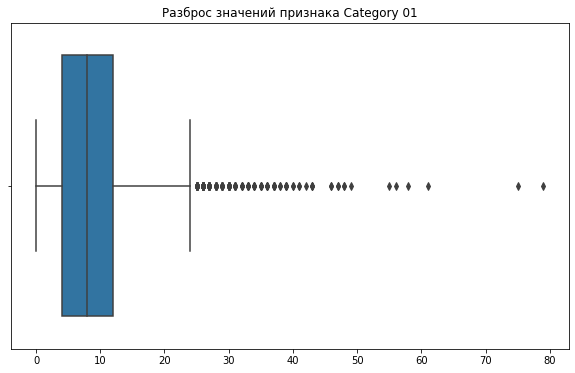

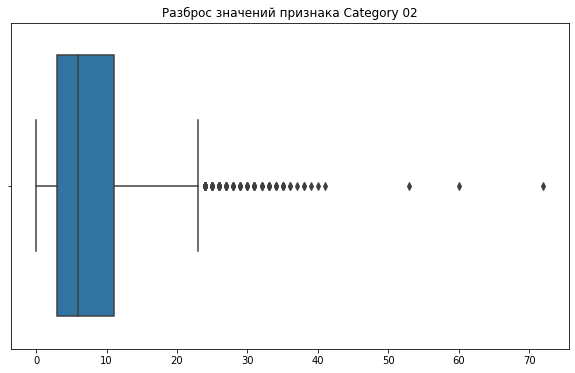

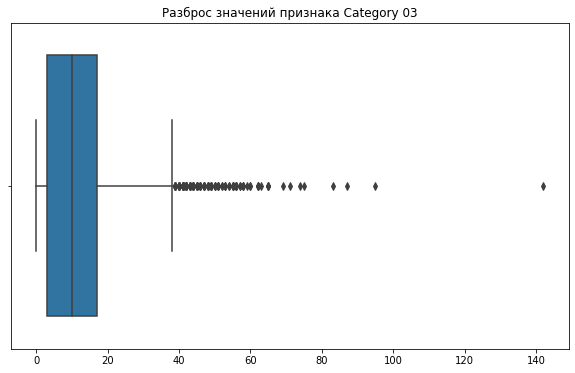

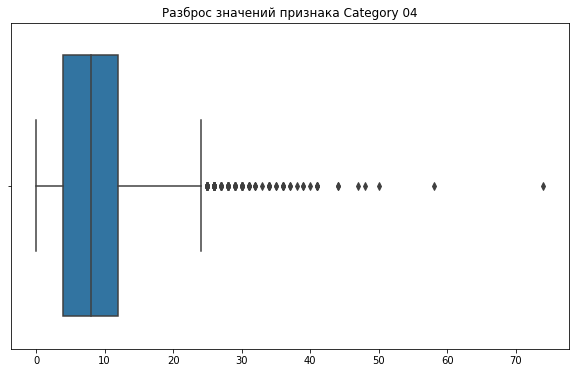

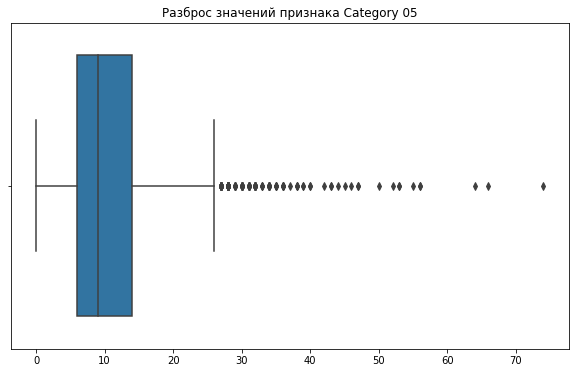

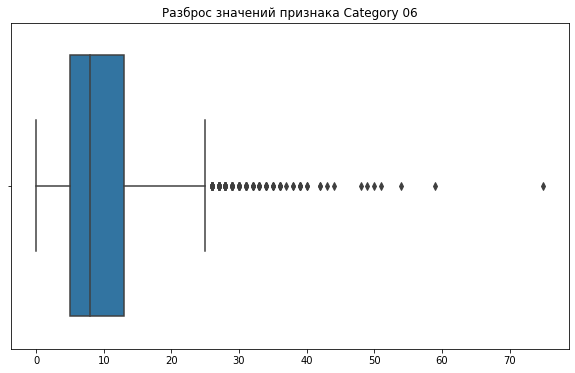

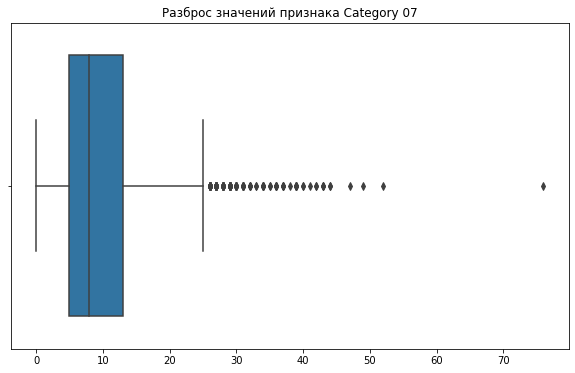

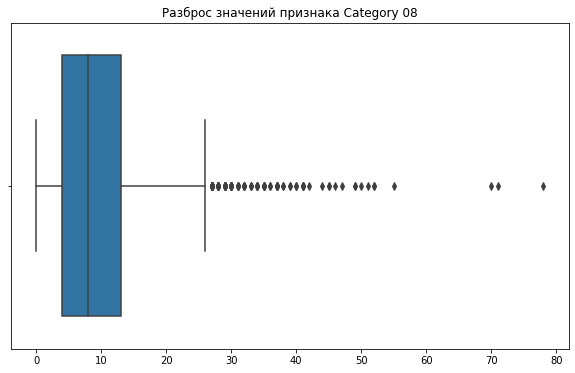

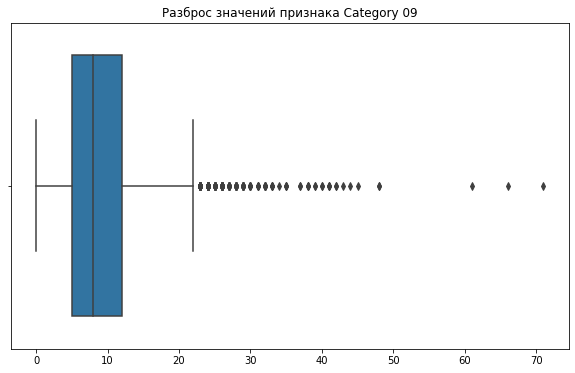

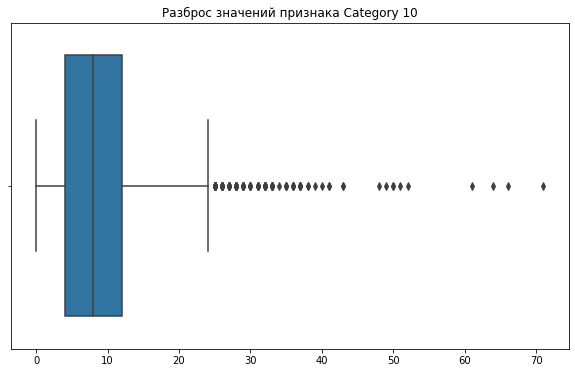

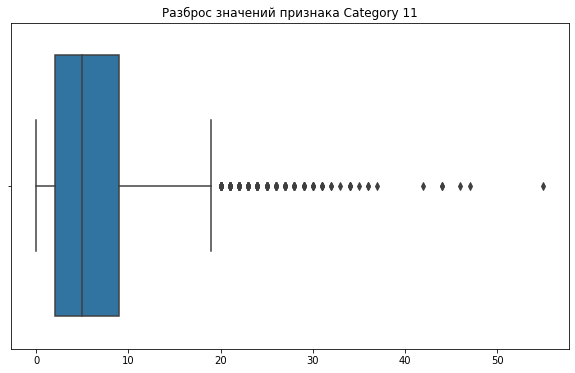

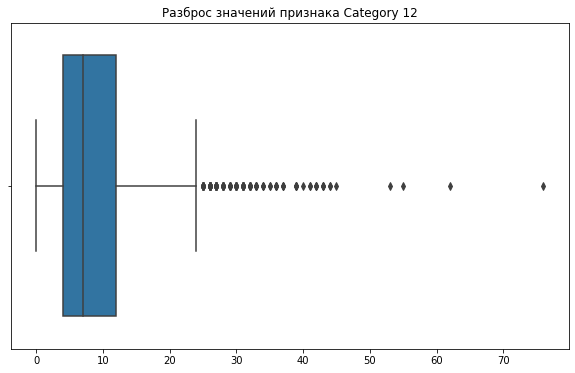

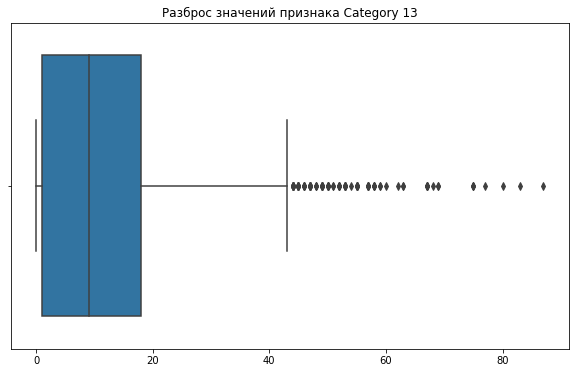

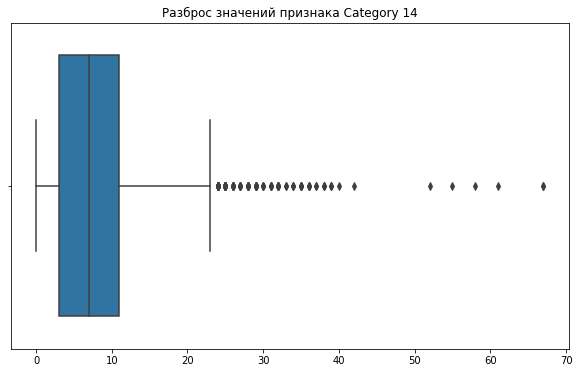

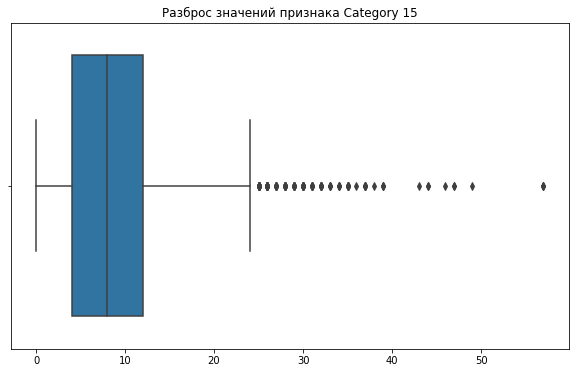

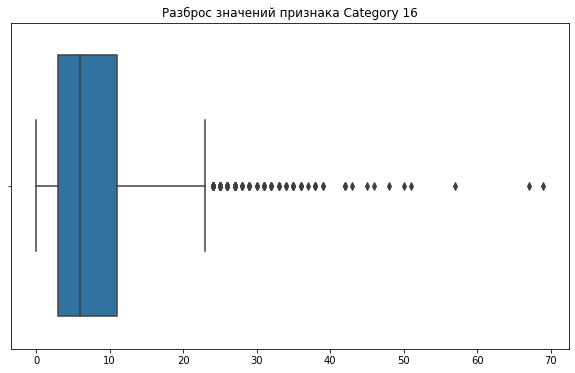

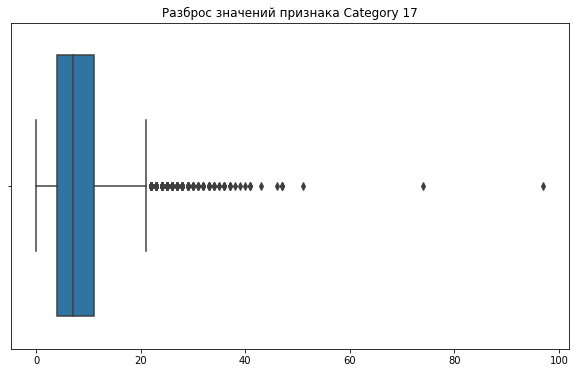

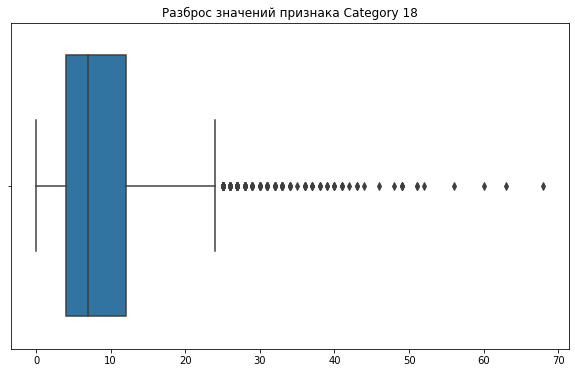

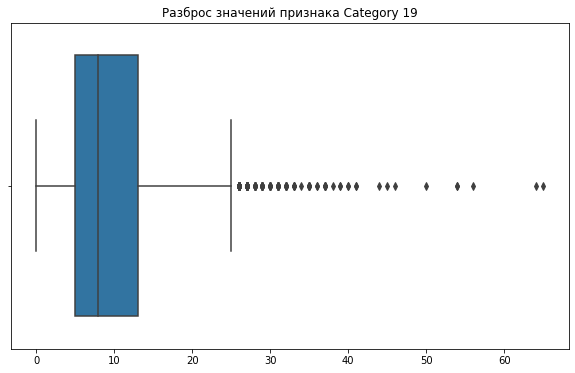

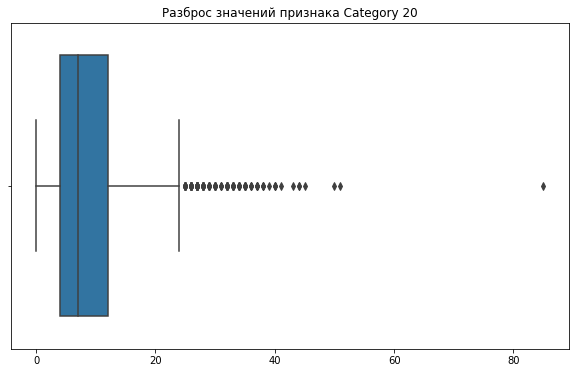

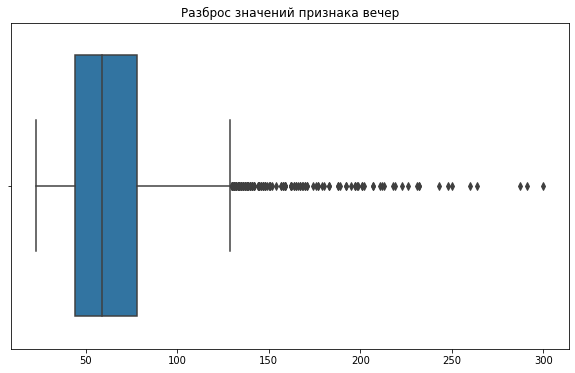

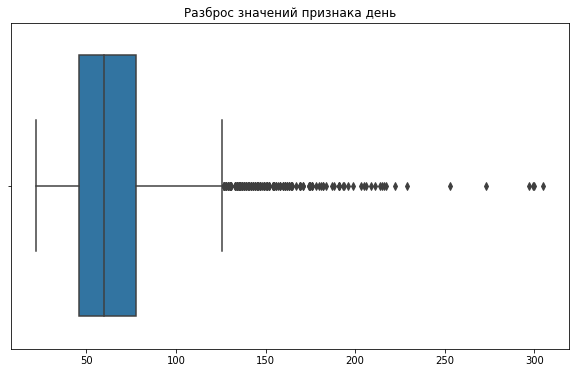

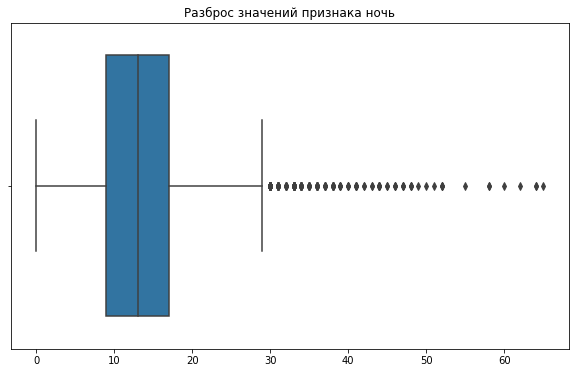

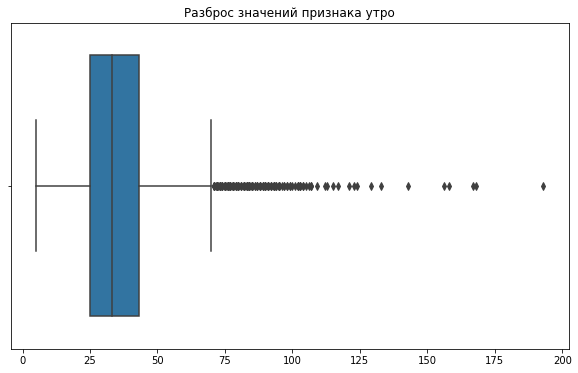

In [24]:
boxplot_cols = ['Category 01', 'Category 02', 'Category 03', 'Category 04',
                'Category 05', 'Category 06', 'Category 07', 'Category 08',
                'Category 09', 'Category 10', 'Category 11', 'Category 12',
                'Category 13', 'Category 14', 'Category 15', 'Category 16',
                'Category 17', 'Category 18', 'Category 19', 'Category 20',
                'вечер', 'день', 'ночь', 'утро']

for col in boxplot_cols:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x=col)
    plt.title(f'Разброс значений признака {col}')
    plt.xlabel('')
    plt.show()

В числовых данных существуют выборосы, но тем не менее они не выглядят столь аномальными чтобы их нужно было дополнительно обрабатывать

interval columns not set, guessing: ['age_category', 'cloud_usage', 'Category 01', 'Category 02', 'Category 03', 'Category 04', 'Category 05', 'Category 06', 'Category 07', 'Category 08', 'Category 09', 'Category 10', 'Category 11', 'Category 12', 'Category 13', 'Category 14', 'Category 15', 'Category 16', 'Category 17', 'Category 18', 'Category 19', 'Category 20', 'вечер', 'день', 'ночь', 'утро']


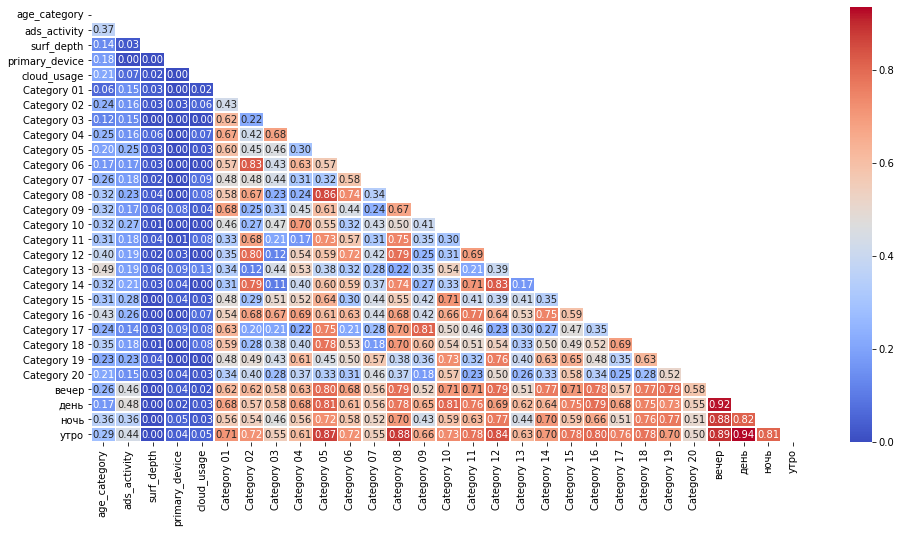

In [25]:
# Матрица корреляций
corr_data = df.drop(columns='user_id').phik_matrix()

plt.figure(figsize=(16, 8))
mask = np.triu(np.ones_like(corr_data, dtype=bool))
sns.heatmap(data=corr_data, annot=True,
            fmt='.2f', linewidths=0.5,
            cmap='coolwarm', mask=mask,)
plt.show()

Промежуточные выводы:
  - В процессе удаления дубликатов и пустых значений было удалено 708 записей (87 при удалении дубликатов и 621 при устранении пустых значений)
  - В целевом признаке "age categoty" обнаружен дисбаланс классов, наибольшее количество записей в 4 классе, наименьшее в 1 классе
  - Во всех числовых признаках были обнаружены выбросы. Было принято решение оставить эти значения в данных
  - Существует множество признаков с высокой корреляцией между собой, наиболее ярко выраженными явлются признаки, характеризующие время обращения к сайту. Все признаки решено оставить для дальнейшенго создания новых признаков на основе текущих

<a id='3'></a>
## Создание и отбор признаков

### Создание новых признаков

In [26]:
# среднее количество сессий каждого пользователя за день
daily_sessions = df_visits.groupby(['user_id', 'date'])['session_id'].nunique().reset_index(name='sessions_count')
avg_sessions_per_user = daily_sessions.groupby('user_id')['sessions_count'].mean().reset_index(name='avg_sessions_per_day')

df = pd.merge(df, avg_sessions_per_user, on='user_id', how='left')

In [27]:
category_columns = ['Category 01', 'Category 02', 'Category 03', 'Category 04',
                    'Category 05', 'Category 06', 'Category 07', 'Category 08',
                    'Category 09', 'Category 10', 'Category 11',
                    'Category 12', 'Category 13', 'Category 14',
                    'Category 15', 'Category 16', 'Category 17', 'Category 18',
                    'Category 19', 'Category 20']

# Пересчитываем в долю, которую пользователь уделяет каждой категории
df[category_columns] = df[category_columns].div(df[category_columns].sum(axis=1), axis=0)

In [28]:
daypart_columns = ['вечер', 'день', 'ночь', 'утро']

# Переводим в долю, в какой части дня активен пользователь
df[daypart_columns] = df[daypart_columns].div(df[daypart_columns].sum(axis=1), axis=0)

interval columns not set, guessing: ['age_category', 'cloud_usage', 'Category 01', 'Category 02', 'Category 03', 'Category 04', 'Category 05', 'Category 06', 'Category 07', 'Category 08', 'Category 09', 'Category 10', 'Category 11', 'Category 12', 'Category 13', 'Category 14', 'Category 15', 'Category 16', 'Category 17', 'Category 18', 'Category 19', 'Category 20', 'вечер', 'день', 'ночь', 'утро', 'avg_sessions_per_day']


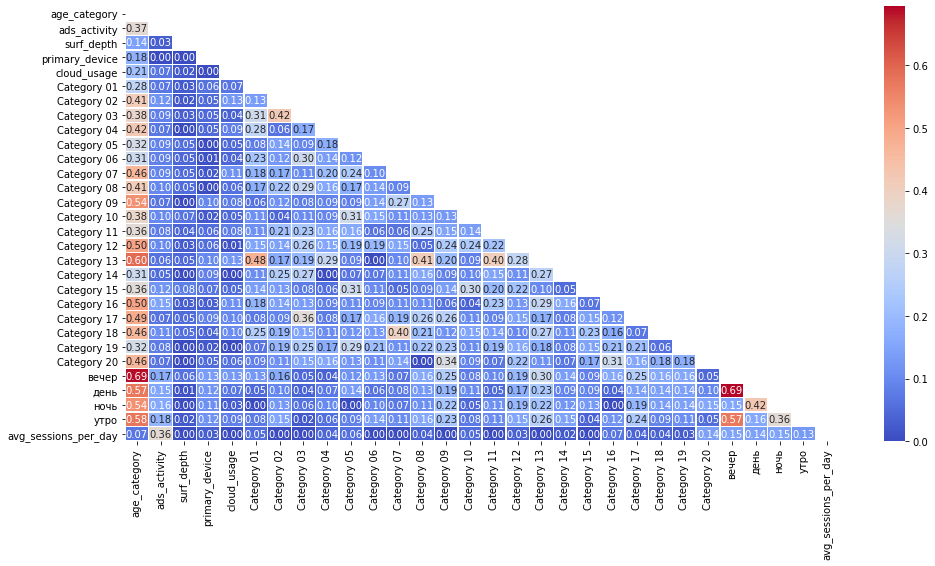

In [29]:
corr_data = df.drop(columns='user_id').phik_matrix()

plt.figure(figsize=(16, 8))
mask = np.triu(np.ones_like(corr_data, dtype=bool))
sns.heatmap(data=corr_data, annot=True,
            fmt='.2f', linewidths=0.5,
            cmap='coolwarm', mask=mask,)
plt.show()

С помощью преобразования признаков пролбема с сильной корреляцией между признаками устранена, а также связь между большей частью признаков и целевой переменной стала более выраженной

In [30]:
def remove_cols(df, cols):
    """ Удаление лишних столбцов """
    
    data = df.copy()
    try:
        for col in cols:
            data = data.drop(columns=col)
    except:
        ...
        
    return data

### Анализ корреляции с целевой переменной

In [31]:
corr_data = df.phik_matrix()

threshold = 0.1
phik_click_correlations = corr_data['age_category'].drop('age_category')

print('\nИз-за низкой корреляции с целевой переменной будут удалены столбцы:\n')
print(phik_click_correlations[phik_click_correlations.values <= threshold])
cols_for_del_by_corr = phik_click_correlations[phik_click_correlations.values <= threshold].index.to_list()

# В трансформер
corr_cols_filter = FunctionTransformer(remove_cols, kw_args={'cols': cols_for_del_by_corr})

interval columns not set, guessing: ['age_category', 'cloud_usage', 'Category 01', 'Category 02', 'Category 03', 'Category 04', 'Category 05', 'Category 06', 'Category 07', 'Category 08', 'Category 09', 'Category 10', 'Category 11', 'Category 12', 'Category 13', 'Category 14', 'Category 15', 'Category 16', 'Category 17', 'Category 18', 'Category 19', 'Category 20', 'вечер', 'день', 'ночь', 'утро', 'avg_sessions_per_day']


/opt/conda/lib/python3.9/site-packages/phik/data_quality.py:59: UserWarning: The number of unique values of variable user_id is large: 5205. Are you sure this is not an interval variable? Analysis for pairs of variables including user_id can be slow.
  warnings.warn(



Из-за низкой корреляции с целевой переменной будут удалены столбцы:

avg_sessions_per_day    0.068673
Name: age_category, dtype: float64


<a id='4'></a>
## Предобработка данных

In [32]:
def preprocess(categorial_features_onehot,
               binary_features,
               numeric_features):

    preprocessor = ColumnTransformer(
        transformers=[
            ('onehot', OneHotEncoder(drop='first',
                     handle_unknown='ignore', sparse_output=False), categorial_features_onehot),
            ('num', StandardScaler(), numeric_features),
            ('bin', 'passthrough', binary_features)
        ]
    )
    
    return preprocessor


In [33]:
categorial_features_onehot = ['ads_activity', 'surf_depth', 'primary_device']

numeric_features = ['Category 01', 'Category 02', 'Category 03', 'Category 04',
                    'Category 05', 'Category 06', 'Category 07', 'Category 08',
                    'Category 09', 'Category 10', 'Category 11',
                    'Category 12', 'Category 13', 'Category 14',
                    'Category 15', 'Category 16', 'Category 17', 'Category 18',
                    'Category 19', 'Category 20', 'вечер', 'день', 'ночь', 'утро']


binary_features = ['cloud_usage']


preprocessor = preprocess(categorial_features_onehot, binary_features, numeric_features)

  - Так как категориальные признаки имеют малую кардинальность, используется OneHotEncoder
  - Числовые данные масштабируются с помощью StandardScaler
  - Бинарный признак 'cloud_usage' никак не обрабатывается

<a id='5'></a>
## Обучение и оценка базовой модели

In [34]:
df = df.drop(columns='user_id')

X = df.drop(columns='age_category')
y = df['age_category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True,
                                                    stratify=y, random_state=RANDOM_SEED)

print(f"Размер тренировочной выборки {X_train.shape[0]} записей")
print(f"Размер тестовой выборки {X_test.shape[0]} записей\n")

print("Распределние целевой переменной в тренировочной выборке")
print(y_train.value_counts() / y_train.shape[0])
print("\nРаспределние целевой переменной в тестовой выборке")
print(y_test.value_counts() / y_test.shape[0])

Размер тренировочной выборки 4164 записей
Размер тестовой выборки 1041 записей

Распределние целевой переменной в тренировочной выборке
4    0.301633
2    0.244236
3    0.216138
0    0.147935
1    0.090058
Name: age_category, dtype: float64

Распределние целевой переменной в тестовой выборке
4    0.301633
2    0.243996
3    0.216138
0    0.147935
1    0.090298
Name: age_category, dtype: float64


In [35]:
pipelines = {
    'dummy' : Pipeline(steps=[
        ('classifier', DummyClassifier(strategy="most_frequent", random_state=RANDOM_SEED))
        ]),
    
    'multi_logistic_regression' : Pipeline(steps=[
        ('corr_cols_filter', corr_cols_filter),
        ('preprocessor', preprocessor),
        ('var_filter', VarianceThreshold(threshold=0.05)),
        ('classifier', LogisticRegression(solver='lbfgs',
                                          random_state=RANDOM_SEED)),
        ]),
    
    'ovo_logistic_regression' : Pipeline(steps=[
        ('corr_cols_filter', corr_cols_filter),
        ('preprocessor', preprocessor),
        ('var_filter', VarianceThreshold(threshold=0.05)),
        ('classifier', OneVsOneClassifier(LogisticRegression(class_weight='balanced', random_state=RANDOM_SEED))),
        ]),
    
    'ovr_logistic_regression' : Pipeline(steps=[
        ('corr_cols_filter', corr_cols_filter),
        ('preprocessor', preprocessor),
        ('var_filter', VarianceThreshold(threshold=0.05)),
        ('classifier', OneVsRestClassifier(LogisticRegression(class_weight='balanced', random_state=RANDOM_SEED))),
        ]),
    
    'ovo_svc' : Pipeline(steps=[
        ('corr_cols_filter', corr_cols_filter),
        ('preprocessor', preprocessor),
        ('var_filter', VarianceThreshold(threshold=0.05)),
        ('classifier', OneVsOneClassifier(SVC(kernel='linear', class_weight='balanced', random_state=RANDOM_SEED)))
        ]),
    
    'ovr_svc' : Pipeline(steps=[
        ('corr_cols_filter', corr_cols_filter),
        ('preprocessor', preprocessor),
        ('var_filter', VarianceThreshold(threshold=0.05)),
        ('classifier', OneVsRestClassifier(SVC(kernel='linear', class_weight='balanced', random_state=RANDOM_SEED)))
        ]),
}

In [36]:
def model_evaluate(model, X, y, n_splits=3):

    scoring_metrics = {
    'accuracy': 'accuracy',
    'precision_macro': make_scorer(precision_score, average='macro', zero_division=0),
    'recall_macro': make_scorer(recall_score, average='macro'),
    'f1_macro': make_scorer(f1_score, average='macro')
    }
    
    outer_cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED)
    
    start_time = time()
    
    cv_results = cross_validate(
        model,
        X, y,
        cv=outer_cv,
        scoring=scoring_metrics,
        n_jobs=-1
    )
    
    end_time = time()
    
    print(f"Время обучения и оценки (CV): {end_time - start_time:.2f} сек.")
    
    print(f"\n--- Средние Метрики Модели---")
    for metric in scoring_metrics.keys():
        mean_value = np.mean(cv_results[f'test_{metric}'])
        std_value = np.std(cv_results[f'test_{metric}'])
        print(f"  Средний {metric}: {mean_value:.4f} (±{std_value:.4f})")
    print("-" * 55)


In [37]:
for pipeline in pipelines:
    print(f'Модель {pipeline}')
    model_evaluate(pipelines[pipeline], X_train, y_train)
    print()

Модель dummy
Время обучения и оценки (CV): 0.04 сек.

--- Средние Метрики Модели---
  Средний accuracy: 0.3016 (±0.0003)
  Средний precision_macro: 0.0603 (±0.0001)
  Средний recall_macro: 0.2000 (±0.0000)
  Средний f1_macro: 0.0927 (±0.0001)
-------------------------------------------------------

Модель multi_logistic_regression
Время обучения и оценки (CV): 2.14 сек.

--- Средние Метрики Модели---
  Средний accuracy: 0.8398 (±0.0054)
  Средний precision_macro: 0.8138 (±0.0101)
  Средний recall_macro: 0.8026 (±0.0044)
  Средний f1_macro: 0.8069 (±0.0067)
-------------------------------------------------------

Модель ovo_logistic_regression
Время обучения и оценки (CV): 3.79 сек.

--- Средние Метрики Модели---
  Средний accuracy: 0.8415 (±0.0071)
  Средний precision_macro: 0.8125 (±0.0075)
  Средний recall_macro: 0.8279 (±0.0040)
  Средний f1_macro: 0.8177 (±0.0066)
-------------------------------------------------------

Модель ovr_logistic_regression
Время обучения и оценки (CV): 5

В результате кросс-валидации на тренировочной выборке по ключевой метрике F1 можно выделить 2 лучших модели:
  - ovo_logistic_regression : F1 = 0.8180
  - ovo_svc : F1 = 0.8138
  
Для обоих попробуем подобрать гиперпараметры и затем выберем лучшую

<a id='6'></a>
## Подбор гиперпараметров моделей

In [38]:
param_grid_ovo_svc = {
    'classifier__estimator__C': [0.01, 0.1, 1, 10, 100],
    'classifier__estimator__kernel': ['linear', 'rbf', 'poly'],
    'classifier__estimator__gamma': ['scale', 'auto', 0.01, 0.1],
    'classifier__estimator__degree': [2, 4],
}
    
param_grid_ovo_logreg = {
    'classifier__estimator__C': [0.01, 0.1, 1, 10, 100],
    'classifier__estimator__penalty': ['l2'],
    'classifier__estimator__solver': ['lbfgs'],
    'classifier__estimator__max_iter': [100, 200, 500],
    'classifier__estimator__class_weight': ['balanced', None],
}

def optimize_model_grid(model, X, y, param_grid, n_splits=3):
    
    start_time = time()

    kfold = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED)
    
    search = GridSearchCV(
        model,
        param_grid,
        cv=kfold,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=1,
        return_train_score=True
    )
    
    search.fit(X, y)
    
    results_df = pd.DataFrame(search.cv_results_)
    
    results_df = results_df.sort_values('rank_test_score')
    
    display_cols = ['rank_test_score', 'mean_test_score', 'std_test_score']
    
    display_cols = [col for col in display_cols if col in results_df.columns]
    
    summary = results_df[display_cols].head(10).copy()
    
    end_time = time()
    
    print(f"\nВремя подбора гиперпараметров: {end_time - start_time:.2f} сек.\n")
    
    return search.best_estimator_, search.best_params_, summary


In [39]:
ovo_logistic_regression_grided, ovo_logistic_regression_params, ovo_logistic_regression_table = optimize_model_grid(
    model=pipelines['ovo_logistic_regression'], 
    X=X_train, 
    y=y_train, 
    param_grid=param_grid_ovo_logreg
)

print(f'Лучшая модель: \n{ovo_logistic_regression_grided}\n')
print(f'Лучшие гиперпараметры: \n{ovo_logistic_regression_params}')
print("Результаты подбора гиперпараметров для ovo_logistic_regression")
ovo_logistic_regression_table

Fitting 3 folds for each of 30 candidates, totalling 90 fits

Время подбора гиперпараметров: 154.54 сек.

Лучшая модель: 
Pipeline(steps=[('corr_cols_filter',
                 FunctionTransformer(func=<function remove_cols at 0x7ff8389fcc10>,
                                     kw_args={'cols': ['avg_sessions_per_day']})),
                ('preprocessor',
                 ColumnTransformer(transformers=[('onehot',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['ads_activity', 'surf_depth',
                                                   'primary_device']),
                                                 ('num', StandardScaler(),
                                                  ['Cat...
                                          

,rank_test_score,mean_test_score,std_test_score
6,1,0.821566,0.006132
7,1,0.821566,0.006132
8,1,0.821566,0.006132
14,4,0.817726,0.006649
12,4,0.817726,0.006649
13,4,0.817726,0.006649
20,7,0.817539,0.006064
19,7,0.817539,0.006064
18,7,0.817539,0.006064
17,10,0.817356,0.001600


In [40]:
ovo_svc_grided, ovo_svc_params, ovo_svc_table = optimize_model_grid(
    model=pipelines['ovo_svc'], 
    X=X_train, 
    y=y_train, 
    param_grid=param_grid_ovo_svc
)

print(f'Лучшая модель: \n{ovo_svc_grided}\n')
print(f'Лучшие гиперпараметры: \n{ovo_svc_params}')
print("Результаты подбора гиперпараметров для ovo_svc")
ovo_svc_table

Fitting 3 folds for each of 120 candidates, totalling 360 fits

Время подбора гиперпараметров: 950.75 сек.

Лучшая модель: 
Pipeline(steps=[('corr_cols_filter',
                 FunctionTransformer(func=<function remove_cols at 0x7ff8389fcc10>,
                                     kw_args={'cols': ['avg_sessions_per_day']})),
                ('preprocessor',
                 ColumnTransformer(transformers=[('onehot',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['ads_activity', 'surf_depth',
                                                   'primary_device']),
                                                 ('num', StandardScaler(),
                                                  ['Cat...
                                        

,rank_test_score,mean_test_score,std_test_score
70,1,0.897968,0.003569
58,1,0.897968,0.003569
61,3,0.894912,0.004497
49,3,0.894912,0.004497
118,5,0.891370,0.004443
94,5,0.891370,0.004443
82,5,0.891370,0.004443
106,5,0.891370,0.004443
52,9,0.889791,0.002122
64,9,0.889791,0.002122


По результатам подбора гиперпараметров наилучшей моделью оказалась ovo_svc с F1-мерой равной 0.895, ее и будем использовать в качестве финальной модели

<a id='7'></a>
## Финальная модель

In [41]:
model_evaluate(ovo_svc_grided, X_test, y_test)

Время обучения и оценки (CV): 0.64 сек.

--- Средние Метрики Модели---
  Средний accuracy: 0.8876 (±0.0103)
  Средний precision_macro: 0.8848 (±0.0125)
  Средний recall_macro: 0.8391 (±0.0141)
  Средний f1_macro: 0.8540 (±0.0129)
-------------------------------------------------------


In [42]:
y_pred_test = ovo_svc_grided.predict(X_test)
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.91      0.92      0.92       154
           1       0.88      0.82      0.85        94
           2       0.92      0.94      0.93       254
           3       0.98      0.93      0.95       225
           4       0.95      0.98      0.96       314

    accuracy                           0.94      1041
   macro avg       0.93      0.92      0.92      1041
weighted avg       0.94      0.94      0.94      1041



<a id='8'></a>
## Подготовка артефактов модели для внедрения

In [43]:
joblib.dump(ovo_svc_grided, 'ovo_svm.joblib')

['ovo_svm.joblib']

In [44]:
class UserAgePredictor(object):
    
    RANDOM_SEED = 42

    category_columns = ['Category 01', 'Category 02', 'Category 03', 'Category 04',
        'Category 05', 'Category 06', 'Category 07', 'Category 08',
        'Category 09', 'Category 10', 'Category 11',
        'Category 12', 'Category 13', 'Category 14',
        'Category 15', 'Category 16', 'Category 17', 'Category 18',
        'Category 19', 'Category 20']
    daypart_columns = ['вечер', 'день', 'ночь', 'утро']


    categorial_features_onehot = ['ads_activity', 'surf_depth', 'primary_device']
    numeric_features = ['Category 01', 'Category 02', 'Category 03', 'Category 04',
                'Category 05', 'Category 06', 'Category 07', 'Category 08',
                'Category 09', 'Category 10', 'Category 11',
                'Category 12', 'Category 13', 'Category 14',
                'Category 15', 'Category 16', 'Category 17', 'Category 18',
                'Category 19', 'Category 20', 'вечер', 'день', 'ночь', 'утро']
    binary_features = ['cloud_usage']

    pipeline = joblib.load('ovo_svm.joblib')
    
    
    def __init__(self, df_users, df_visits,
                 df_ads_activity, df_surf_depth,
                 df_primary_device, df_cloud_usage):
        
        self.df_users = df_users
        self.df_visits = df_visits
        self.df_ads_activity = df_ads_activity
        self.df_surf_depth = df_surf_depth
        self.df_primary_device = df_primary_device
        self.df_cloud_usage = df_cloud_usage
        

    def remove_duplicates(self):
        ''' Удаление дубликатов '''
        
        self.df_users = self.df_users.drop_duplicates(subset=['user_id'])
        self.df_ads_activity = self.df_ads_activity.drop_duplicates(subset=['user_id'])
        self.df_surf_depth = self.df_surf_depth.drop_duplicates(subset=['user_id'])
        self.df_primary_device = self.df_primary_device.drop_duplicates(subset=['user_id'])
        self.df_cloud_usage = self.df_cloud_usage.drop_duplicates(subset=['user_id'])
        self.df_visits = self.df_visits.drop_duplicates()
    

    def data_merging(self):
        ''' Объединение в один датафрейм '''
        
        df_visits_cat = pd.crosstab(self.df_visits['user_id'], self.df_visits['website_category']).reset_index()
        df_visits_daytime = pd.crosstab(self.df_visits['user_id'], self.df_visits['daytime']).reset_index()

        df = pd.merge(self.df_users, self.df_ads_activity, on='user_id', how='left')
        df = pd.merge(df, self.df_surf_depth, on='user_id', how='left')
        df = pd.merge(df, self.df_primary_device, on='user_id', how='left')
        df = pd.merge(df, self.df_cloud_usage, on='user_id', how='left')
        df = pd.merge(df, df_visits_cat, on='user_id', how='left')
        df = pd.merge(df, df_visits_daytime, on='user_id', how='left')
    
        return df
    
    @staticmethod
    def remove_na(df):
        ''' Удаление пустых значений '''
        
        data = df.copy()
        data = data.dropna()
        return data
        
    
    def append_new_cols(self, df):
        ''' Добавление новых признаков '''
        
        # среднее количество сессий каждого пользователя за день
        daily_sessions = self.df_visits.groupby(['user_id', 'date'])['session_id'].nunique().reset_index(name='sessions_count')
        avg_sessions_per_user = daily_sessions.groupby('user_id')['sessions_count'].mean().reset_index(name='avg_sessions_per_day')

        df = pd.merge(df, avg_sessions_per_user, on='user_id', how='left')
        
        # Пересчитываем в долю, которую пользователь уделяет каждой категории
        df[category_columns] = df[category_columns].div(df[category_columns].sum(axis=1), axis=0)
        
        # Переводим в долю, в какой части дня активен пользователь
        df[daypart_columns] = df[daypart_columns].div(df[daypart_columns].sum(axis=1), axis=0)
        
        return df

    @staticmethod
    def data_split(df, test_size=0.2):
        ''' Разделение на тренировочную и тестовую выборки '''
        
        df = df.drop(columns='user_id')
        X = df.drop(columns='age_category')
        y = df['age_category']
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, shuffle=True,
                                                            stratify=y, random_state=RANDOM_SEED)
        return X_train, X_test, y_train, y_test
    
    
    def model_evaluate(self, X, y, n_splits=3):
        ''' Оценка метрик модели '''
        
        scoring_metrics = {
        'accuracy': 'accuracy',
        'precision_macro': make_scorer(precision_score, average='macro', zero_division=0),
        'recall_macro': make_scorer(recall_score, average='macro'),
        'f1_macro': make_scorer(f1_score, average='macro')
        }

        outer_cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=self.RANDOM_SEED)

        start_time = time()

        cv_results = cross_validate(
            self.pipeline,
            X, y,
            cv=outer_cv,
            scoring=scoring_metrics,
            n_jobs=-1
        )

        end_time = time()

        print(f"Время обучения и оценки (CV): {end_time - start_time:.2f} сек.")

        print(f"\n--- Средние Метрики Модели---")
        for metric in scoring_metrics.keys():
            mean_value = np.mean(cv_results[f'test_{metric}'])
            std_value = np.std(cv_results[f'test_{metric}'])
            print(f"  Средний {metric}: {mean_value:.4f} (±{std_value:.4f})")
        print("-" * 55)
        
        
    def make_pred(self, X):
        ''' Предсказания модели '''
        
        y_pred = self.pipeline.predict(X)
        return y_pred


In [45]:
age_predictor  = UserAgePredictor(df_users, df_visits, df_ads_activity, df_surf_depth, df_primary_device, df_cloud_usage)
age_predictor.remove_duplicates()
merged_df = age_predictor.data_merging()
cleaned_df = age_predictor.remove_na(merged_df)
final_df = age_predictor.append_new_cols(cleaned_df)
X_train_0, X_test_0, y_train_0, y_test_0 = age_predictor.data_split(final_df)
age_predictor.model_evaluate(X_train_0, y_train_0)
predictions = age_predictor.make_pred(X_test_0)

Время обучения и оценки (CV): 4.48 сек.

--- Средние Метрики Модели---
  Средний accuracy: 0.9157 (±0.0026)
  Средний precision_macro: 0.9040 (±0.0052)
  Средний recall_macro: 0.8934 (±0.0028)
  Средний f1_macro: 0.8980 (±0.0036)
-------------------------------------------------------


In [46]:
if predictions.all() == y_test.all():
    print('Модели одинаковые')

Модели одинаковые


<a id='9'></a>
## Выводы о результатах работы

  - Наилучшей стратегией для предсказания возраста посетителей сайтов оказалась OneVsOneClassifier с базовой моделью SVM.
  - Полученная модель оказалась ~10 раз лучше базовой Dummy модели, значение F1-macro меры на тренировочной выборке составляет 0.895, на тестовой выборке 0.856
  - Метрики модели удвовлетворяют техническим требованиям заказчика и может быть рекомендована к внедрению